# YZ50 — Week 4: Activations, Gradients & BatchNorm

- After building the MLP language model, the focus shifts to understanding **what happens inside the network during training** by examining its activations and gradients.

- **Tanh saturation** occurs when activations approach -1 or 1, causing the gradients to become very small and making learning difficult.

- **Weight initialization** determines the initial scale of activations and gradients. **Kaiming initialization** helps keep these values in a more useful range at the beginning of training.

- **BatchNorm (Batch Normalization)** normalizes hidden-layer activations using statistics from each minibatch during training, helping stabilize the network and improve optimization.

- The same MLP is also trained on the **Turkish name dataset** from the previous week to examine how the model performs on Turkish character sequences.

In this part, I analyze **activations and gradients**, investigate **tanh saturation**, apply **Kaiming initialization**, compare models with and without **BatchNorm**, and evaluate the model on **Turkish names**.

# Continuing to Build Makemore: A Deeper Look at Activations, Gradients & BatchNorm

# 5. Part 3'e geç. Aynı modelde başlangıç loss'unun neden çok yüksek olduğunu ve tanh'ın neden doyduğunu göster, videodaki histogramı çizdir. Kaiming init ile ağırlıkları ölçekle, iki sorunun da düzeldiğini göster.

In [101]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [102]:
# read in all the words
words = open('../data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [103]:
len(words)

32033

In [104]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [105]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])        # %80
Xdev, Ydev = build_dataset(words[n1:n2])    # %10
Xte, Yte = build_dataset(words[n2:])        # %10

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [106]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [107]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.9356
  20000/ 200000: 2.5331
  30000/ 200000: 2.9308
  40000/ 200000: 2.1004
  50000/ 200000: 2.4989
  60000/ 200000: 2.4067
  70000/ 200000: 2.1295
  80000/ 200000: 2.3477
  90000/ 200000: 2.3098
 100000/ 200000: 2.0809
 110000/ 200000: 2.3818
 120000/ 200000: 2.0194
 130000/ 200000: 2.4772
 140000/ 200000: 2.2544
 150000/ 200000: 2.1509
 160000/ 200000: 2.0979
 170000/ 200000: 1.8214
 180000/ 200000: 1.9808
 190000/ 200000: 1.8395


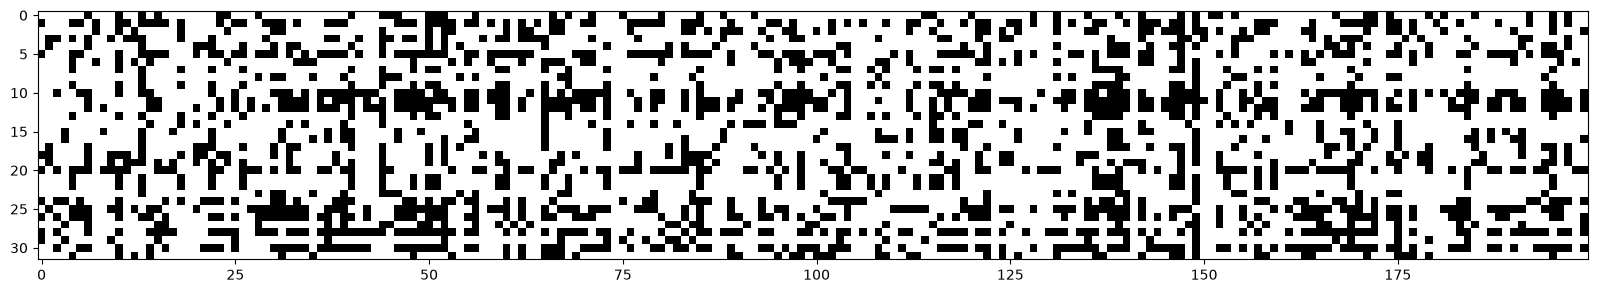

In [108]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

### Activation Saturation

Each **column** represents a neuron, while each **row** represents an example. Therefore, each cell shows the activation value of a specific neuron for a specific example.

The white cells indicate neurons whose activation is very high in magnitude (`|h| > 0.99`), meaning they are operating near the saturation region of `tanh`.

If an entire column is white, that neuron is **dead**: it is saturated for every example, receives almost no gradient, and therefore **cannot effectively learn**.

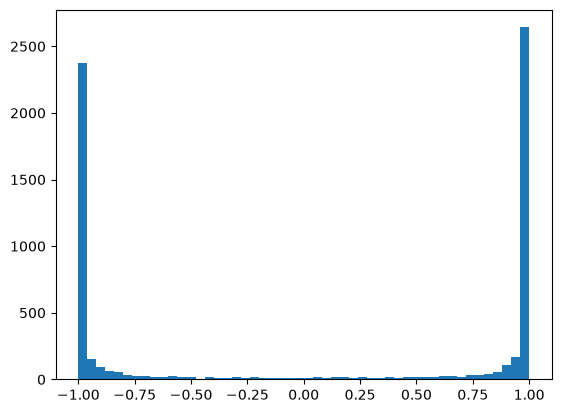

In [109]:
plt.hist(h.view(-1).tolist(),50);

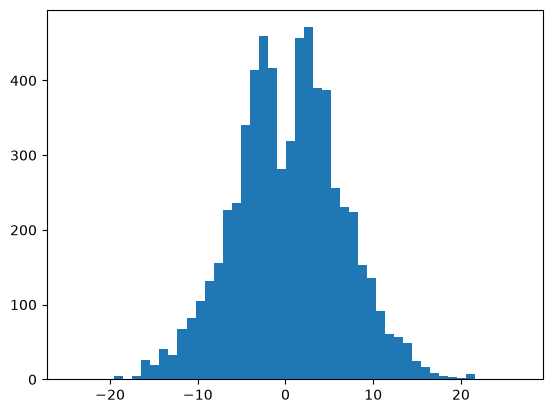

In [110]:
plt.hist(hpreact.view(-1).tolist(),50);

## 2.nd Problem Tanh Activation Distribution

<div align="center">
    <img src="../images/tanh.png" width="750">
</div>

After applying `tanh`, the activations are limited to the range `[-1, 1]`. However, in this case, most activations are concentrated very close to **-1 and +1**.

This is problematic because `tanh` **saturates** at its extremes.

The derivative of `tanh` is:

```python
tanh'(x) = 1 - tanh(x)**2

When the activation is close to -1 or +1:

self.grad = tanh'(x) * out.grad

tanh(x) ≈ ±1
        ↓
1 - tanh(x)² ≈ 0

So during backpropagation, the gradient gets multiplied by a value close to zero:

gradient
   ↓
× tanh'(x)
   ↓
× ~0
   ↓
very small gradient

This causes the vanishing gradient problem. The gradients flowing back through the tanh layer become very small, so earlier layers receive very little information about how their weights should change.

As a result:

Earlier layers learn very slowly.
Training becomes less efficient.
The network can have difficulty improving its parameters.

Ideally, we want the pre-activations to be mostly around the linear region of tanh, near 0.

Around zero:

tanh(0) = 0
tanh'(0) = 1

This allows gradients to pass through effectively.

In short: The problem is not that tanh outputs values in [-1, 1]. The problem is that too many activations are near -1 or +1, where tanh saturates and its derivative becomes almost zero, causing gradients to vanish during backpropagation.

### ReLU and Zero Gradients

<div align="center">
    <img src="../images/Relu.png" width="750">
</div>

The ReLU activation function is defined as:

$$
\text{ReLU}(x) = \max(0, x)
$$

Its derivative is:

$$
\text{ReLU}'(x) =
\begin{cases}
0 & x < 0 \\
1 & x > 0
\end{cases}
$$

When the pre-activation value is negative, the ReLU output is `0`, so:

$$
\text{gradient} = \text{ReLU}'(x) \cdot out.grad
= 0 \cdot out.grad = 0
$$

Therefore, the neuron receives **no gradient and cannot update its parameters**. If it remains negative, it becomes a **dead ReLU neuron** and cannot learn.

Unlike `tanh`, where the gradient becomes **very small** near saturation, ReLU has a gradient that is **exactly zero** for negative inputs.

### Both **tanh saturation** (gradients approaching zero) and **ReLU dead neurons** (gradients becoming exactly zero) can occur due to **random initialization** or during **optimization** as the model's parameters are updated.

Once a neuron becomes dead, if **no example activates it again**, it receives no gradient, its parameters are never updated, and the **neuron remains dead forever** — essentially, **permanent brain damage in a neural network**.

Unlike ReLU, **Leaky ReLU** maintain a non-zero gradient for negative inputs, so they **do not suffer from the dead neuron problem in the same way**.

In [111]:
# This is the loss that we would expect if we were to guess each character uniformly at random. It is used as a baseline to compare the model's performance against random guessing.
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [112]:
# 4-dimensional example of the issue
#logits = torch.tensor([-3.0, 5.0, 0.0, 2.0])
logits = torch.randn(4) * 10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([-14.5132,  -0.5930,  -5.0066,  10.9718]),
 tensor([8.5509e-12, 9.4942e-06, 1.1499e-07, 9.9999e-01]),
 tensor(15.9784))

## 1.th Problem Why the Loss Changes Randomly

The logits are randomly sampled using `torch.randn(4)`, which produces values from a standard normal distribution. Multiplying them by `10` makes the logits much larger in magnitude.

Because `softmax` is very sensitive to differences between large logits, small changes in the randomly generated logits can cause the probability distribution to change drastically.

Here, the loss is calculated for the class at **index 2**:

```python
loss = -probs[2].log()
```

If the random logits give a high value to index 2, `probs[2]` becomes large and the loss is small. However, if another index gets a much larger logit than index 2, most of the probability is assigned to that other class, making `probs[2]` very small and the loss very large.

In short:

> **Random logits + scaling by 10 → large logit differences → highly concentrated softmax probabilities → randomly very small or very large loss.**

### Desired Initialization

When the network is initialized, we generally want the logits to be roughly around zero rather than having very large positive or negative values. This keeps the initial softmax probabilities relatively balanced and prevents the model from starting with an overly confident prediction.

## Solution for 1.th Problem Why We Initialize `W2` and `b2` This Way

```python
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
```

We initialize `W2` with small random values (`* 0.01`) so that the initial logits remain **close to zero**. This prevents the softmax from becoming overly confident at initialization and helps keep the initial loss relatively low and stable.

We **do not initialize `W2` to exactly zero** because that would make all output neurons behave identically. Since every output neuron would receive the same weights, they would produce the same gradients and remain symmetric during training.

Instead, using small random values breaks this symmetry while keeping the initial logits close to zero.

For `b2`, multiplying by `0` makes all biases exactly zero. This is fine because biases do not suffer from the same symmetry problem as weights. The small random values in `W2` are enough to break the symmetry between output neurons.

> **In short:** `W2 ≈ 0` keeps the initial logits small, while random values prevent all output neurons from learning the exact same thing.


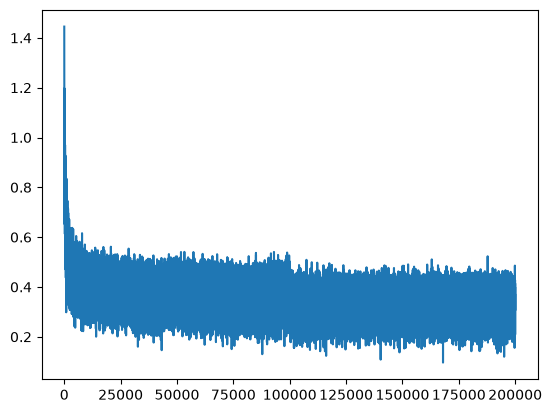

In [113]:
plt.plot(lossi)

In [114]:
@torch.no_grad() # this decorator disables gradient tracking
# This function computes the loss on a given split of the data (train, val, or test) without tracking gradients. It retrieves the appropriate input and target tensors based on the specified split, performs a forward pass through the model, computes the logits, and calculates the cross-entropy loss. Finally, it prints the loss value for the specified split.
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1265742778778076
val 2.170107841491699


In [115]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carlah.
amori.
kahlin.
shreety.
skanden.
jazonen.
den.
art.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quint.
salin.
alianni.
wazelo.
dearynix.
kaeliighan.


### Reinitialize the network after applying solutions

In [134]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.3
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [135]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3177
  10000/ 200000: 2.1900
  20000/ 200000: 2.3264
  30000/ 200000: 2.5377
  40000/ 200000: 1.9461
  50000/ 200000: 2.3406
  60000/ 200000: 2.3606
  70000/ 200000: 2.1198
  80000/ 200000: 2.3053
  90000/ 200000: 2.1876
 100000/ 200000: 1.8506
 110000/ 200000: 2.0824
 120000/ 200000: 1.9077
 130000/ 200000: 2.4039
 140000/ 200000: 2.1159
 150000/ 200000: 2.1429
 160000/ 200000: 1.8024
 170000/ 200000: 1.7497
 180000/ 200000: 2.0089
 190000/ 200000: 1.8745


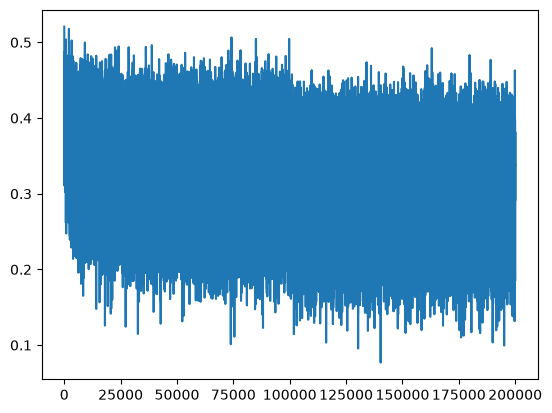

In [136]:
plt.plot(lossi)

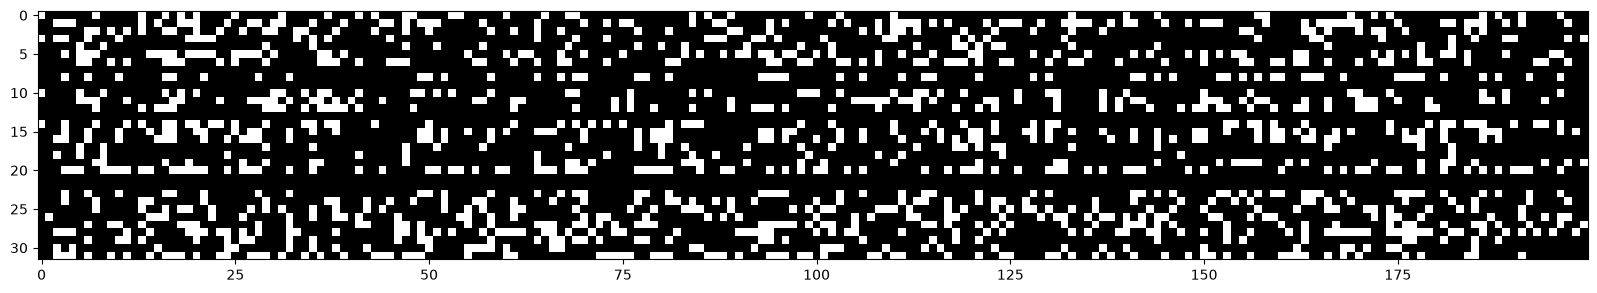

In [137]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

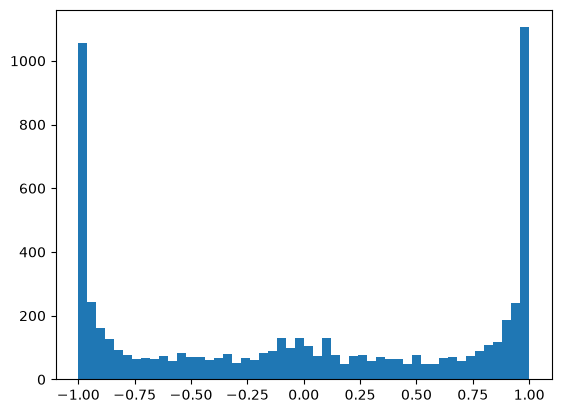

In [139]:
plt.hist(h.view(-1).tolist(),50);

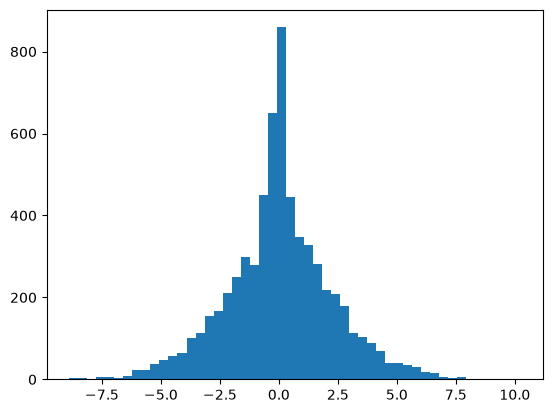

In [140]:
plt.hist(hpreact.view(-1).tolist(),50);

In [141]:
split_loss('train')
split_loss('val')

train 2.0379140377044678
val 2.107375144958496


In [142]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmahzamelle.
khyrmoni.
taty.
skany.
kenleine.
farelynn.
kaeli.
nellara.
chaiivan.
legyn.
ham.
jois.
quint.
salin.
alianni.
waveron.
jaryxin.
kaellissa.
med.
edi.
